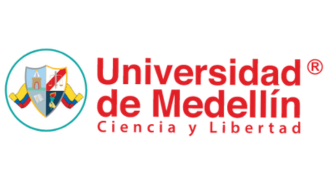

#**ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL**

#*APRENDIZAJE AUTOMÁTICO EN LA NUBE - MLOps*

# Trabajo Final

Prof. Maria Camila Durango Barrera

Est. Eloisa Cardona Botero - Simón Callejas Pérez - Luisa Fernanda Escobar Gutiérrez

# Librerias

In [2]:
pip install ucimlrepo

   ---------------------------------------- 0.0/153.7 kB ? eta -:--:--
   ----------------------- ---------------- 92.2/153.7 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 153.7/153.7 kB 4.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/9.9 MB 14.2 MB/s eta 0:00:01
   -------- ------------------------------- 2.0/9.9 MB 26.0 MB/s eta 0:00:01
   ---------------------- ----------------- 5.7/9.9 MB 40.4 MB/s eta 0:00:01
   ---------------------------------------  9.9/9.9 MB 57.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 48.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -------------- ------------------------- 4.5/12.6 MB 146.3 MB/s eta 0:00:01
   ------------------------- -------------- 8.0/12.6 MB 102.3 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.6 MB 93.9 MB/s eta 0:00:01
   ------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Base de datos a trabajar - Bank Marketing

## Origen de los datos

Los datos están relacionados con campañas de marketing directo de una institución bancaria portuguesa. El objetivo de clasificación es predecir si el cliente contratará un depósito a plazo (variable y). Las campañas de marketing se basaron en llamadas telefónicas. A menudo, se requirió más de un contacto con el mismo cliente para evaluar si el producto (depósito a plazo bancario) sería suscrito (‘sí’) o no (‘no’).

| Nombre de la variable | Rol     | Tipo        | Demográfico        | Descripción | Unidades | Valores faltantes |
|----------------------|---------|-------------|--------------------|-------------|----------|-------------------|
| age                  | Feature | Entero      | Edad               |             |          | no                |
| job                  | Feature | Categórica  | Ocupación          | tipo de trabajo (categórico: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown') |          | no |
| marital              | Feature | Categórica  | Estado civil       | estado civil (categórico: 'divorced','married','single','unknown'; nota: 'divorced' incluye divorciado o viudo) |          | no |
| education            | Feature | Categórica  | Nivel educativo    | (categórico: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown') |          | no |
| default              | Feature | Binaria     |                    | ¿tiene crédito en incumplimiento? |          | no |
| balance              | Feature | Entero      |                    | balance promedio anual | euros   | no |
| housing              | Feature | Binaria     |                    | ¿tiene préstamo hipotecario? |          | no |
| loan                 | Feature | Binaria     |                    | ¿tiene préstamo personal? |          | no |
| contact              | Feature | Categórica  |                    | tipo de comunicación de contacto (categórico: 'cellular','telephone') |          | sí |
| day_of_week          | Feature | Fecha       |                    | día de la semana del último contacto |          | no |
| month                | Feature | Fecha       |                    | mes del último contacto (categórico: 'jan', 'feb', 'mar', ..., 'nov', 'dec') |          | no |
| duration             | Feature | Entero      |                    | duración del último contacto en segundos. Nota: influye fuertemente en la variable objetivo; debería excluirse en modelos predictivos realistas | segundos | no |
| campaign             | Feature | Entero      |                    | número de contactos realizados durante esta campaña para este cliente (incluye el último contacto) |          | no |
| pdays                | Feature | Entero      |                    | número de días desde el último contacto de una campaña previa (-1 significa que no fue contactado previamente) |          | sí |
| previous             | Feature | Entero      |                    | número de contactos realizados antes de esta campaña para este cliente |          | no |
| poutcome             | Feature | Categórica  |                    | resultado de la campaña de marketing previa (categórico: 'failure','nonexistent','success') |          | sí |
| y                    | Target  | Binaria     |                    | ¿el cliente se suscribió a un depósito a plazo? |          | no |

## Cargar los datos

In [35]:
# NOTA: NO MODIFICAR LAS SIGUIENTES 2 LÍNEAS, YA QUE MUESTRAN MEJOR EL DATAFRAME AL HACER "PRINT" O "HEAD"
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [5]:
# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

# Comprensión de la base de datos

In [6]:
X_cat = X[["job","marital","education", "contact", "poutcome"]]
X_num = X[["age","balance","duration","campaign","pdays","previous"]]
X_bin = X[["default","housing","loan"]]

In [7]:
df = pd.concat([X, y], axis=1)


display(df)

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN,no


**Observación**

Solo concatenamos las variables predictoras con nuestra variable target (Y) para poder visualizar todo el dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


**Observación**

Nuestro dataset continiene 45,211 instancias y 17 variables, a primera vista podemos ver que hay variables con valores faltantes, por ejemplo `concat` con 32,191 valores no nulos, y la variable `poutcome`con tan solo 8252 valores no nulos. 

In [8]:
missing = df.isnull().sum()
missing[missing > 0]

job            288
education     1857
contact      13020
poutcome     36959
dtype: int64

In [11]:
df.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


**Observación**

Al hacer .describe() notamos lo siguiente:

1. En primera instancia no tenemos valores faltantes para nuestras variables numéricas.
2. La variable `balance` nos muestra la existencia de valores negativos, lo cual nos puede indicar posibles outliers o clientes que simplemente tienen saldo negativo. También notamos que el promedio esta en 1362.27 mientras que la desviación estandar la tenemos en 3044.76, lo cual nos indica que hay mucha variablidad y lo mismo, outliers.
3. También podemos ver gran variabilidad en con la variable `Duration` ya que tiene un min de 0 y el max es de 4918.
4. con la variable `pdays` recordamos que -> "(numeric; -1 means client was not previously contacted)"


In [24]:
numeric_variables= ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

table_result = pd.DataFrame({
    'mean': df[numeric_variables].mean(),
    'median': df[numeric_variables].median(),
    'mode': df[numeric_variables].mode().iloc[0]
})

table_result

,mean,median,mode
age,40.936210,39.0,32
balance,1362.272058,448.0,0
duration,258.163080,180.0,124
campaign,2.763841,2.0,1
pdays,40.197828,-1.0,-1
previous,0.580323,0.0,0


## **Variables Categóricas y Binarias**

In [12]:
specific_columns = list(X_cat.columns) + list(X_bin.columns) # seleccionamos las columnas que queremos analizar (categóricas y binarias)

for column in specific_columns:
    print(f"\nValue counts per column: {column}")
    counts = df[column].value_counts(dropna=False) # Incluimos los NaN counts
    percentages = df[column].value_counts(normalize=True, dropna=False) * 100 # Incluir NaN percentages

    # Combinamos los counts y porcentajes en un nuevo df
    combined_info = pd.DataFrame({'Count': counts, 'Percentage': percentages})
    combined_info.index.name = column # Set index name for clarity
    print(combined_info.to_string(formatters={'Percentage': '{:.2f}%'.format}))
    print("-" * 50) # Separador para mejor lectura


Value counts per column: job
               Count Percentage
job                            
blue-collar     9732     21.53%
management      9458     20.92%
technician      7597     16.80%
admin.          5171     11.44%
services        4154      9.19%
retired         2264      5.01%
self-employed   1579      3.49%
entrepreneur    1487      3.29%
unemployed      1303      2.88%
housemaid       1240      2.74%
student          938      2.07%
NaN              288      0.64%
--------------------------------------------------

Value counts per column: marital
          Count Percentage
marital                   
married   27214     60.19%
single    12790     28.29%
divorced   5207     11.52%
--------------------------------------------------

Value counts per column: education
           Count Percentage
education                  
secondary  23202     51.32%
tertiary   13301     29.42%
primary     6851     15.15%
NaN         1857      4.11%
-----------------------------------------------

**Observación**

Esto fue con el fin de poder ver la distribución de cada subconjunto dentro de nuestras variables categóricas. Podemos observar algunas distribuciones muy desbalanceadas, pero que, dentro de la realidad, tienen sentido a la hora de promocionar la suscripción a un depósito.

Por ejemplo, para la variable `job`, tenemos que los tipos de empleo a los cuales están más dirigidas estas campañas de marketing son:

1. blue-collar
2. management
3. technician
4. admin

Podemos inferir que esto se debe a que estas personas tienen mayor capacidad de para hacer un depósito; sin embargo, este desbalance podría afectar el desempeño del modelo, dándole más peso a estas clases mayoritarias.

También tiene sentido que dentro de la campaña se contacte más a las personas casadas, ya que de esta forma se puede asumir una mayor estabilidad económica para aceptar un depósito.

En cuanto a la variable `loan`, podemos destacar el gran desbalance entre personas que no tienen un préstamo, las cuales posiblemente estén más dispuestas a adquirir el depósito.

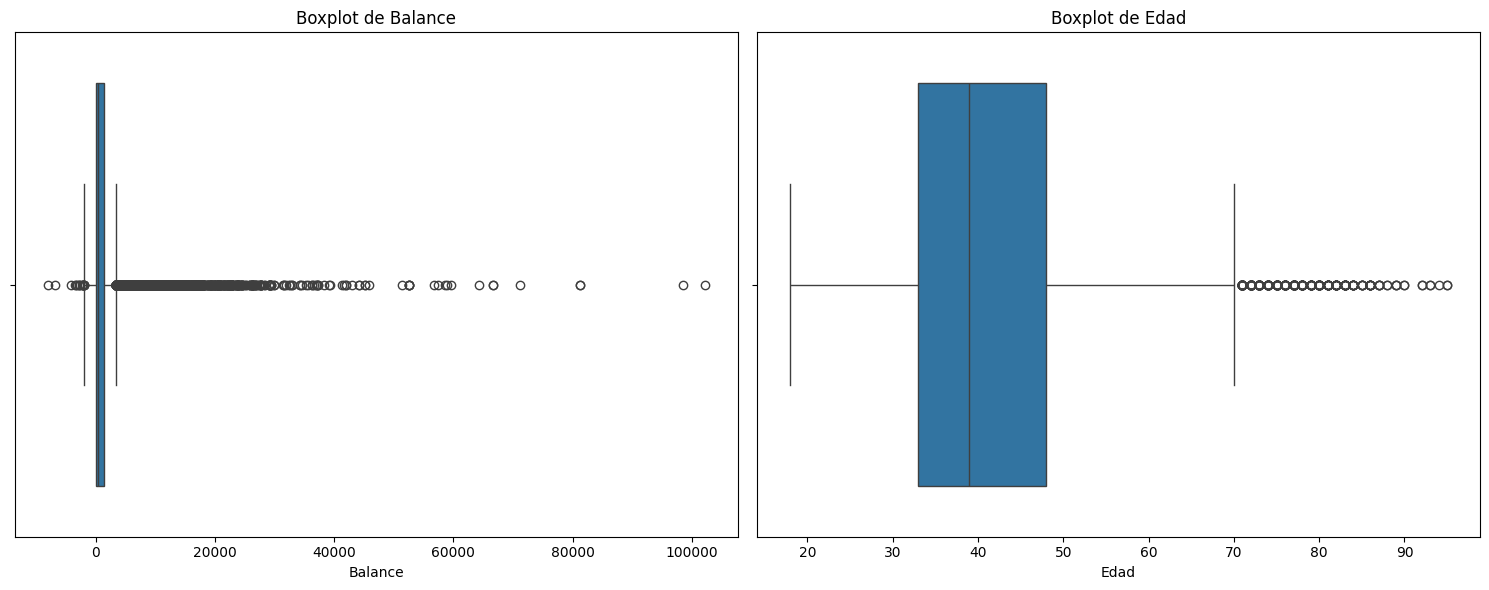

In [14]:
# Variables balance y edad
balance_data = X['balance']
age_data = X['age']

plt.figure(figsize=(15, 6))

# La Variable balance
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.boxplot(x=balance_data)
plt.title('Boxplot de Balance')
plt.xlabel('Balance')
plt.ylabel('')

# La Variable age
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(x=age_data)
plt.title('Boxplot de Edad')
plt.xlabel('Edad')
plt.ylabel('')

plt.tight_layout()
plt.show()

**Observación**

1. Podemos ver como la variable `age` muestra una distribución mucho más estable que `balance`, por ejemplo la gran cantidad de esfuerzo se concentra en edades entre los 30 y 50 años, y si notamos algunos outliers, mas arriba en .describe() podemos ver que la edad max es de 95 años, pero esta no es la norma
2. `balance` si nos confirma lo que resultó de hacer .describe(), hay muchos outliers y algunos valores negativos, posiblemente personas endeudadas. 



## **Variable Target "y"**

In [ ]:
y.value_counts()

,count
y,
no,39922
yes,5289


C:\Users\elois\AppData\Local\Temp\ipykernel_27188\3998381133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y='Count', data=plot_df, palette='viridis')


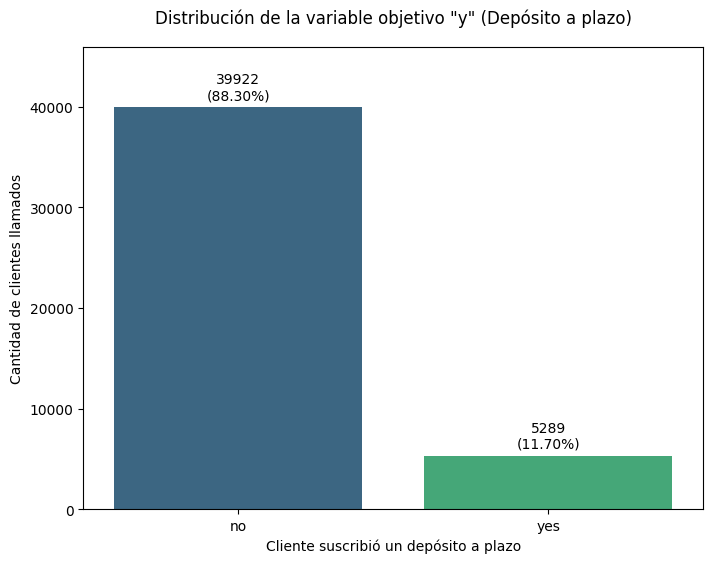

In [34]:
# Calculamos la cantidad y el porcentaje de cada valor en 'y'
y_counts = df['y'].value_counts()
y_percentages = df['y'].value_counts(normalize=True) * 100

# Creamos el df para el gráfico de barras
plot_df = pd.DataFrame({
    'Value': y_counts.index,
    'Count': y_counts.values,
    'Percentage': y_percentages.values
})

# Gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x='Value', y='Count', data=plot_df, palette='viridis')

# AñadiMOS etiquetas de cantidad y porcentaje en las barras
for index, row in plot_df.iterrows():
    plt.text(index, row['Count'] + 500, 
             f"{row['Count']}\n({row['Percentage']:.2f}%)", 
             color='black', ha="center", va='bottom')
    
plt.ylim(0, max(plot_df['Count']) * 1.15)
plt.title('Distribución de la variable objetivo "y" (Depósito a plazo)',pad=17)
plt.xlabel('Cliente suscribió un depósito a plazo')
plt.ylabel('Cantidad de clientes llamados')
plt.show()

# **Correlaciones**

## **Correclación Variables Catégoricas**

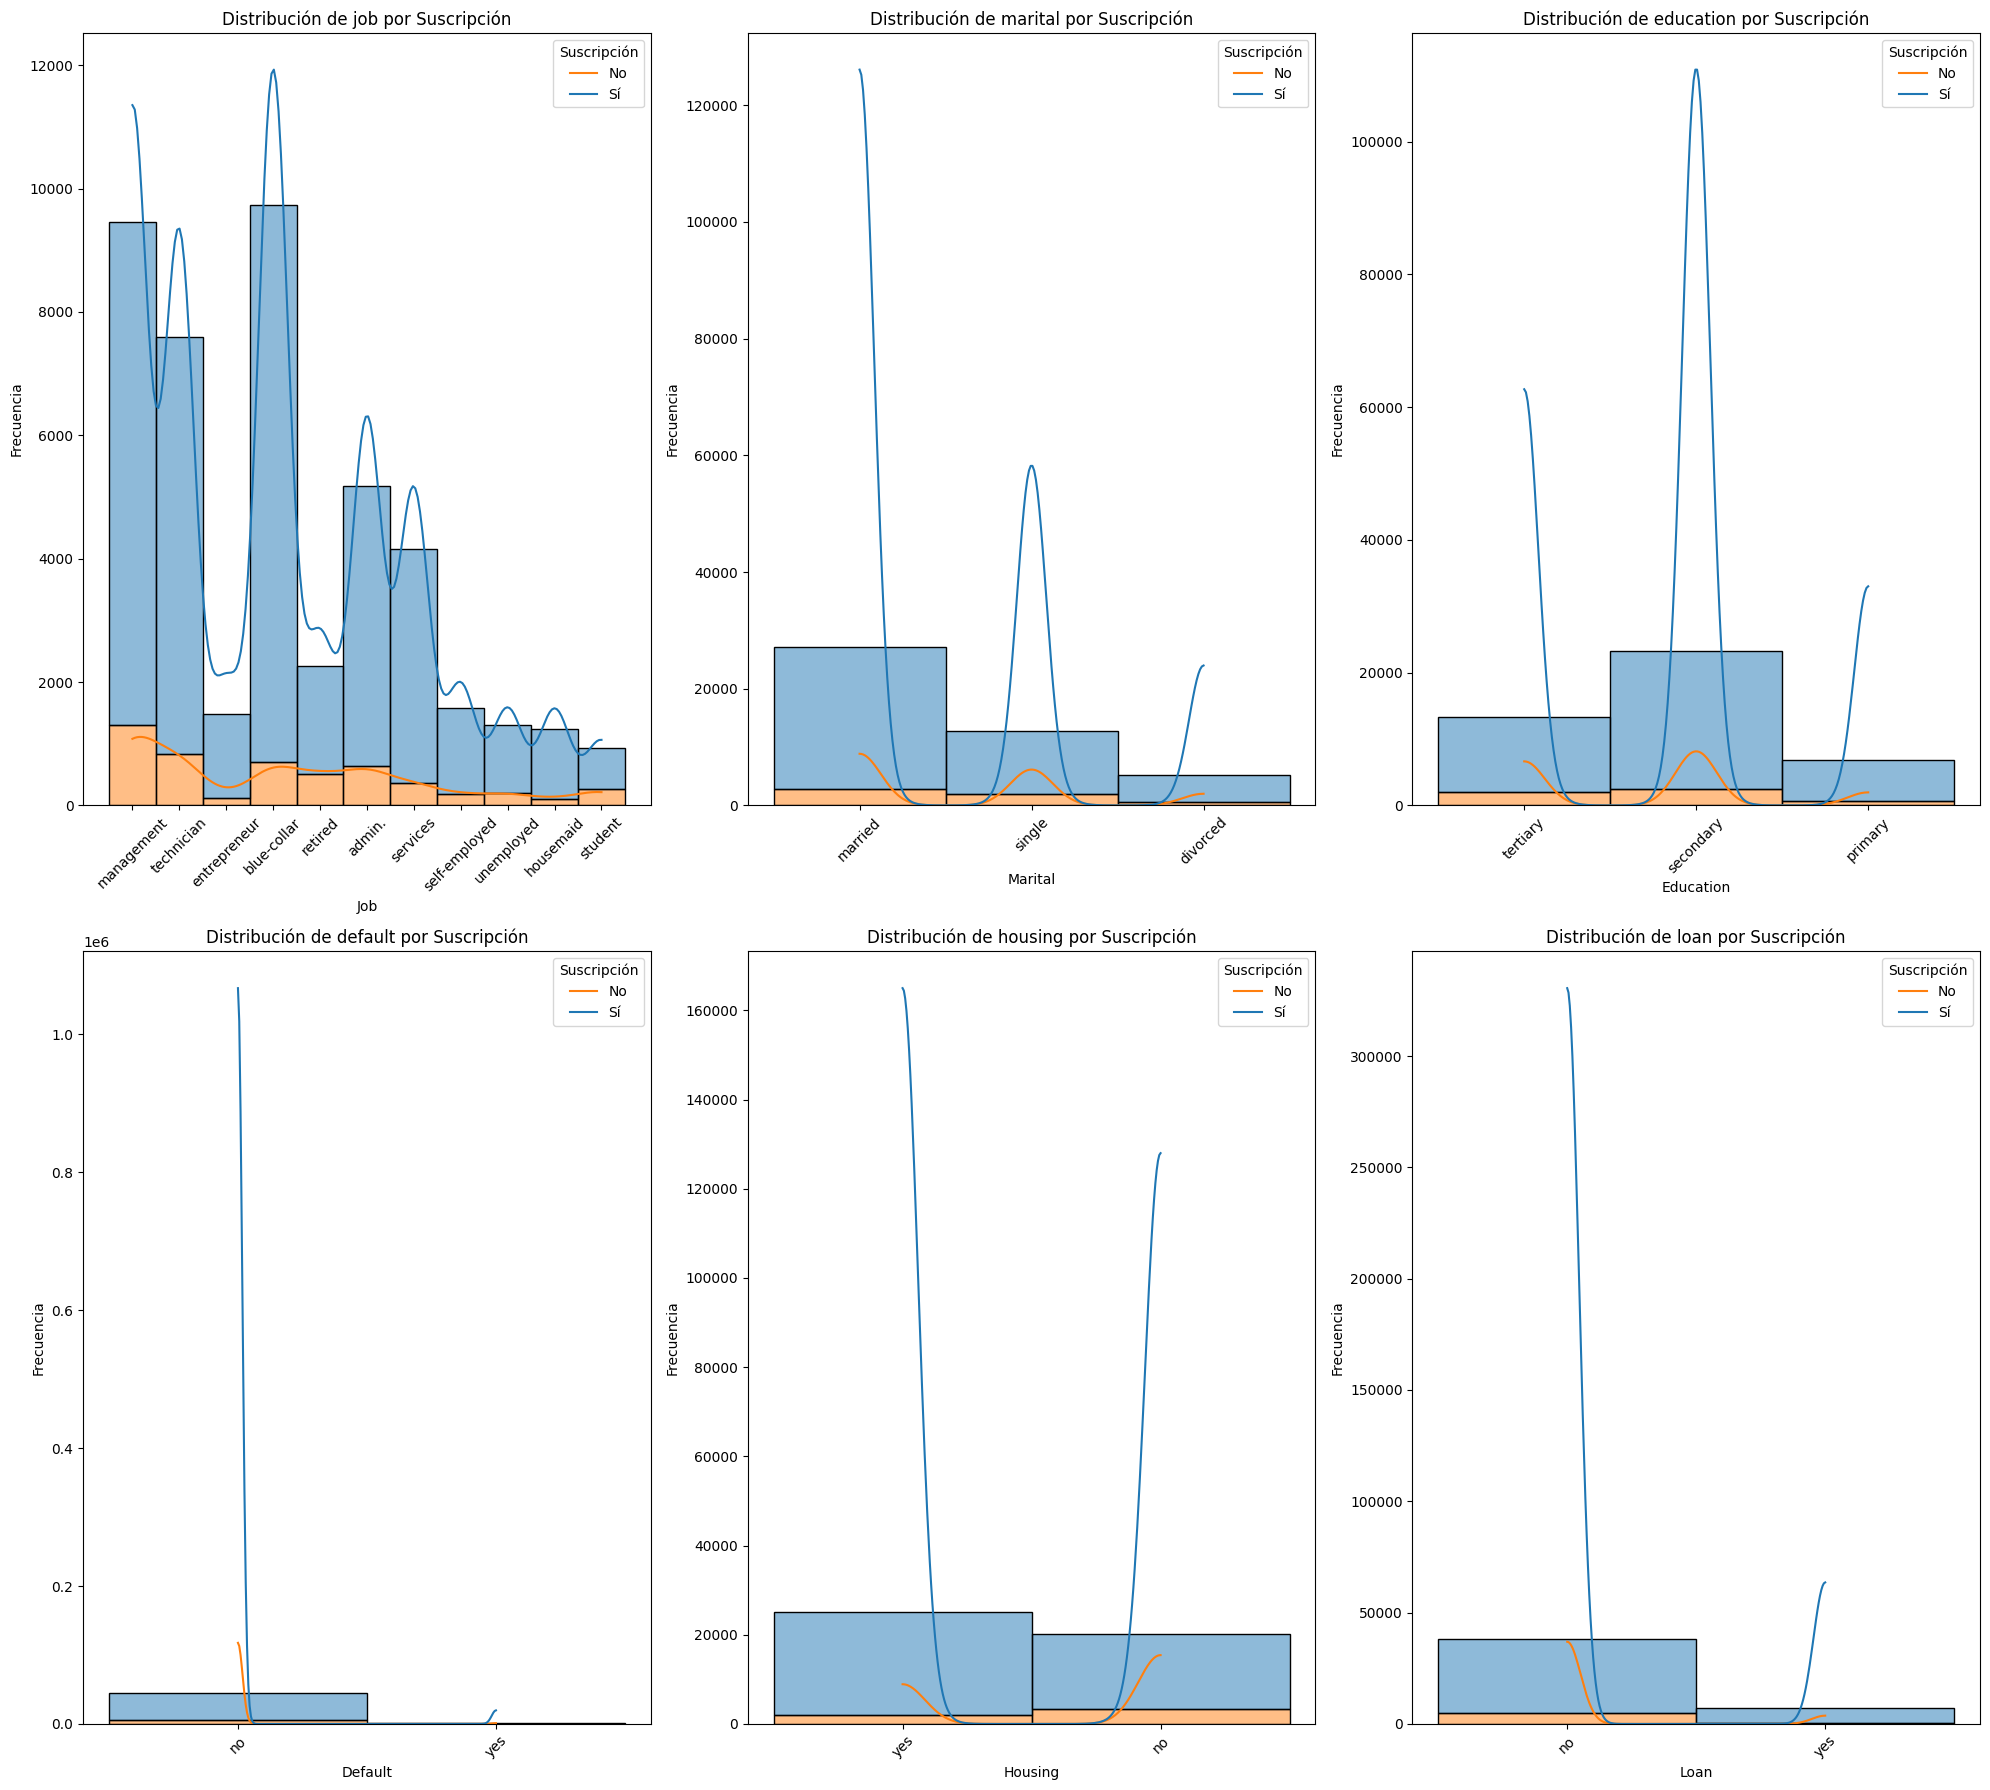

In [38]:
categorical_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Create a 3x2 grid for the subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 18))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, var in enumerate(categorical_vars):
    sns.histplot(data=df, x=var, hue='y', multiple='stack', ax=axes[i], kde=True)
    axes[i].set_title(f'Distribución de {var} por Suscripción')
    axes[i].set_xlabel(var.capitalize())
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Suscripción', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

**Observación**

Podemos concluir lo siguiente:

1. Las profesiones con mayor interés por parte de la empresa son management, technician, blue-collar y admin.
2. Los clientes casados son más frecuentes dentro de los contactados, en comparación con los solteros o divorciados.
3. Las personas con educación secundaria y terciaria suelen presentar mucho mas esfuerzo dentro de la campaña.
4. Las personas que no presentan incumplimientos en créditos suelen estar más abiertas a solicitar uno.
5. Las personas que no cuentan con un crédito hipotecario pueden estar mas abiertas a adquirir un depósito.
6. Aquellas personas que no cuentan con un préstamo suelen estar más abiertas a solicitar uno nuevo.

## **Correlación Variables Numéricas**

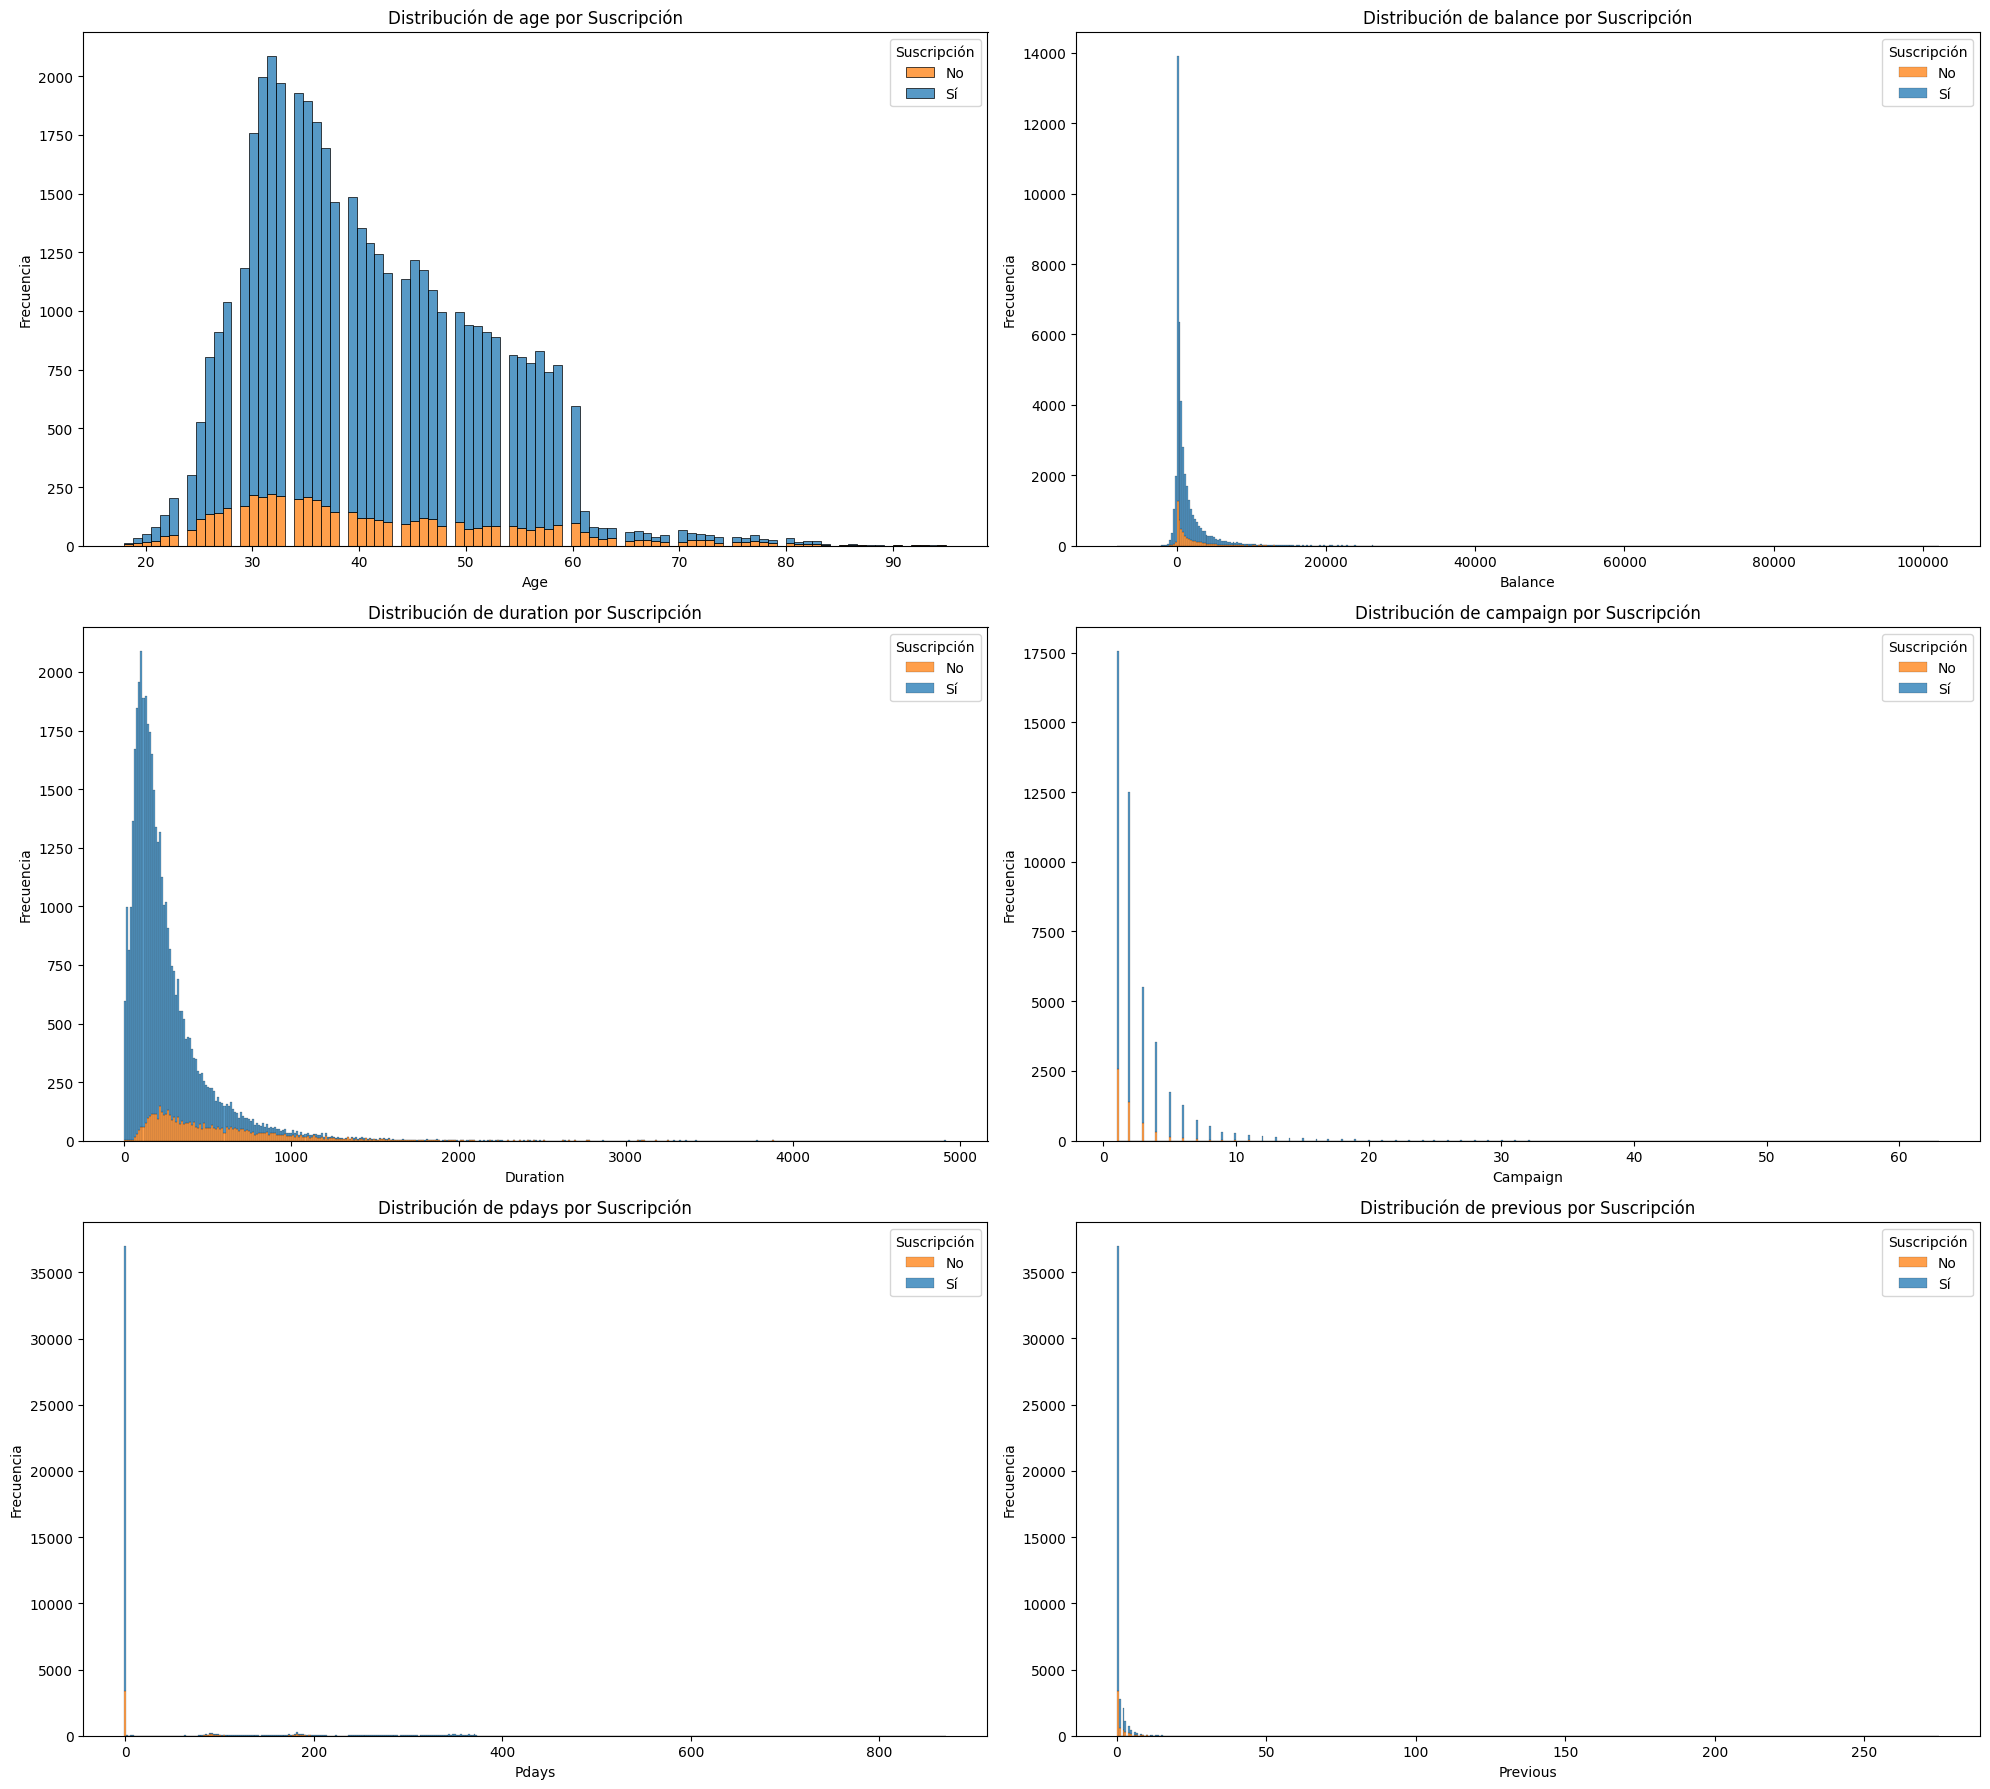

In [42]:
numeric_vars = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# Grid de subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 18))
axes = axes.flatten()

for i, var in enumerate(numeric_vars):
    sns.histplot(data=df, x=var, hue='y',  multiple='stack', ax=axes[i])
    axes[i].set_title(f'Distribución de {var} por Suscripción')
    axes[i].set_xlabel(var.capitalize())
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(title='Suscripción', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

**Observación**

1. La variable `age` sigue mostrando que los valores donde hay mayor concentración es entre 25 y 40 años. 
2. Podemos ver que `balance` no muestra una separación clara entre clientes que aceptan o no el depósito, ademas, muchos de estos demuestran que sus cuentas estan en 0, con deuda o con muy poca actividad. 
3. `duration` con esta variable queda un poco claro que es un elemento muy predictivo, a mayor duración de la llamada, mayor es la proporoción de clientes que si aceptan.
4. Para `campaign` vemos que en general los clientes son contactos pocas veces, y a medida que se les contacta mas veces, la posibilidad de aceptación disminuye cada vez mas.
5. para `pdays` confirmamos que gran cantidad de clientes no había sido contactados previamente, lo cual concuerda un poco con `previous` ya que la mayoría de estas personas no tenían hidtorial de haber sido contactados.



# **Heatmap Variables Numéricas**

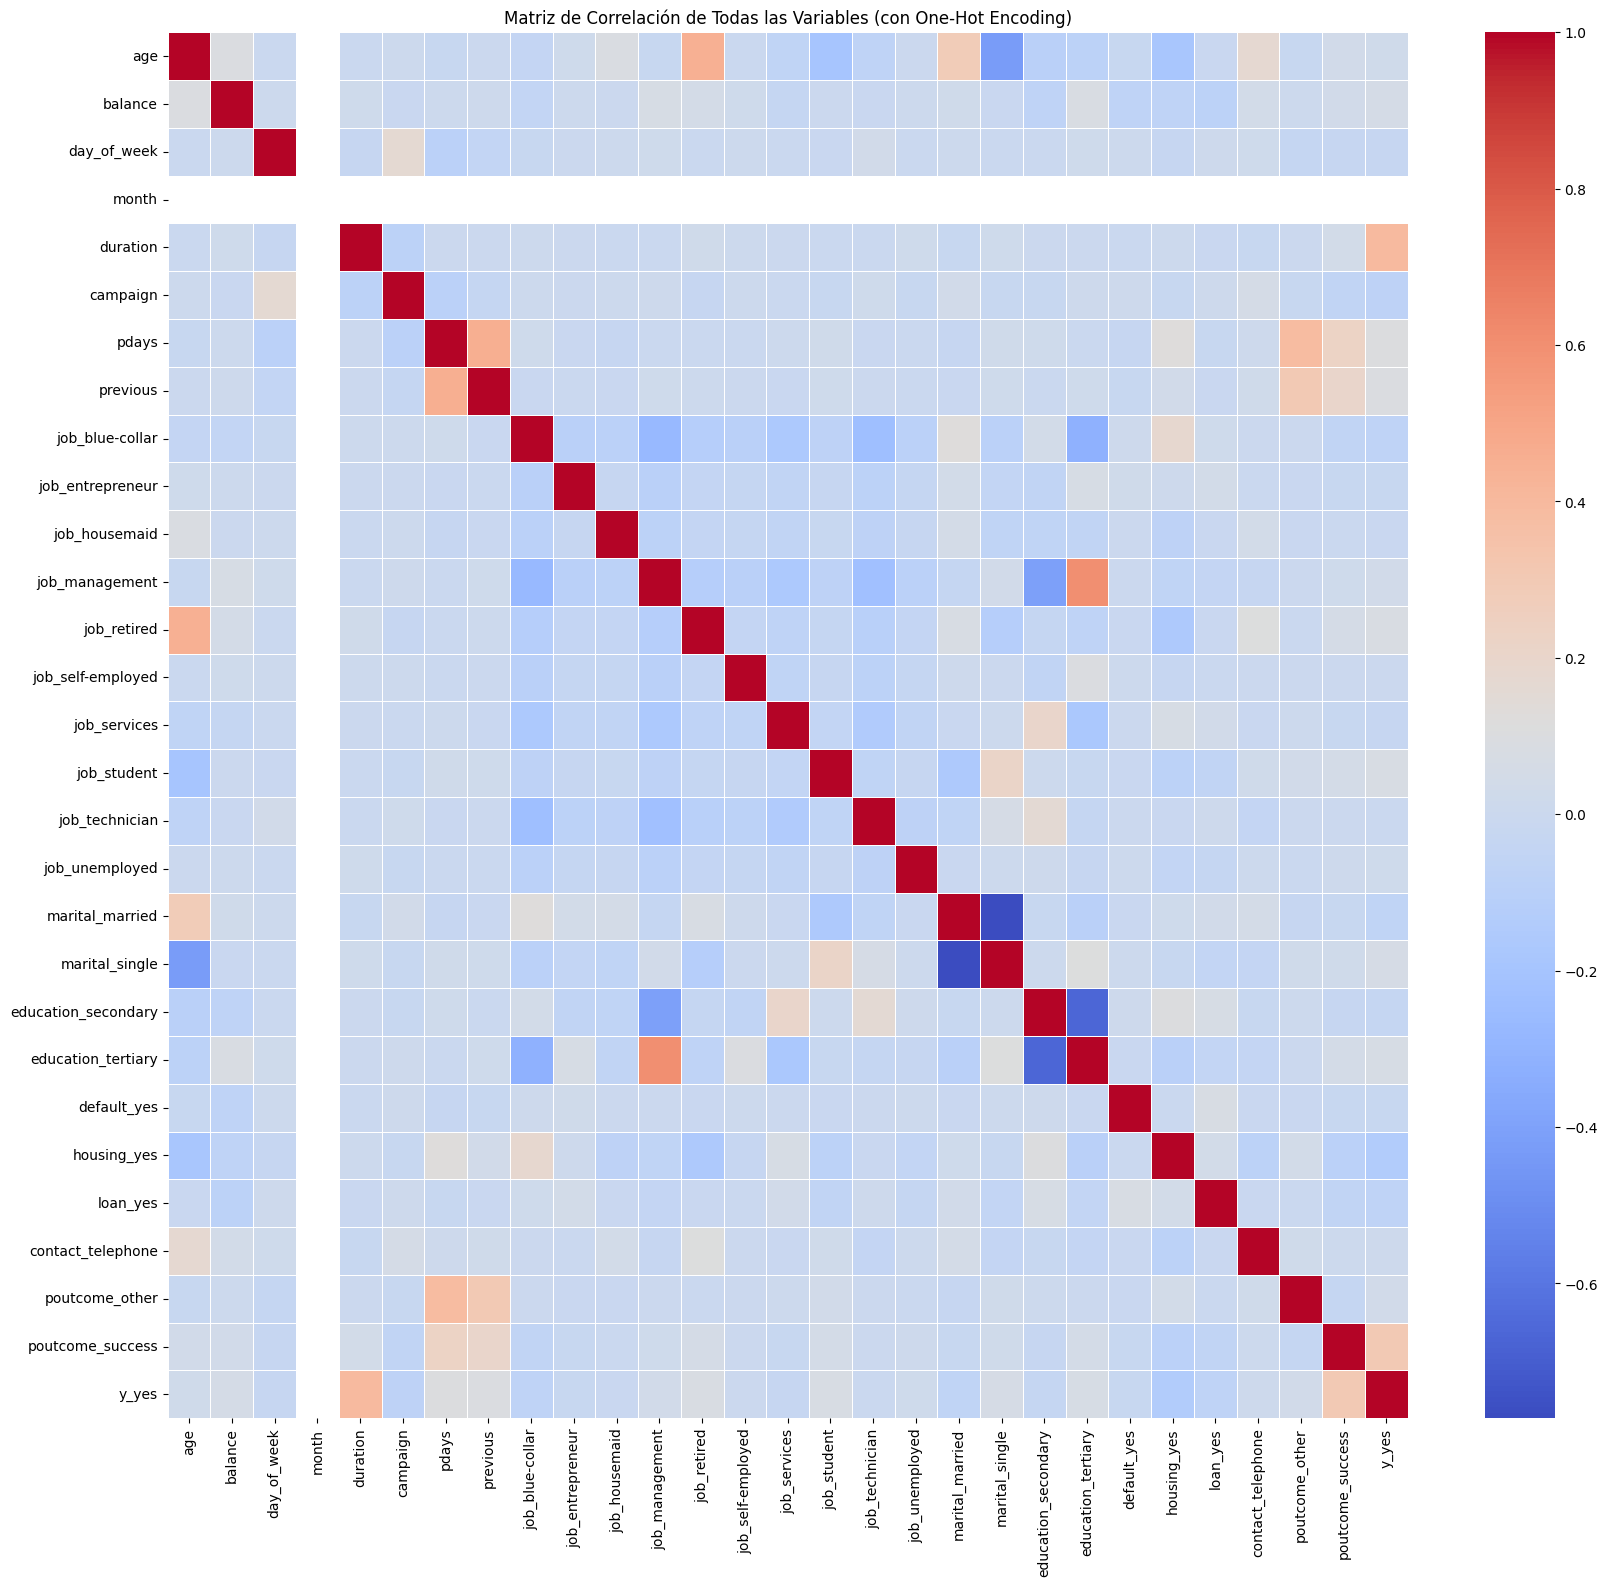

In [45]:
# Seleccionar las columnas categóricas para One-Hot Encoding, incluyendo el target 'y'
# Se excluyen 'day_of_week' y 'month' para simplificar la visualización del heatmap
# ya que suelen tener muchas categorías y pueden hacer el heatmap muy denso o irrelevante
# para las correlaciones generales si no se manejan específicamente.

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'y']

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # drop_first para evitar multicolinealidad

# Asegurarse de que todas las columnas sean numéricas para la correlación
df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce')

# Calcular la matriz de correlación
correlation_matrix = df_encoded.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(20, 18)) # Ajustar el tamaño para una mejor visualización
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Todas las Variables (con One-Hot Encoding)')
plt.show()

## **Matriz de correlación**

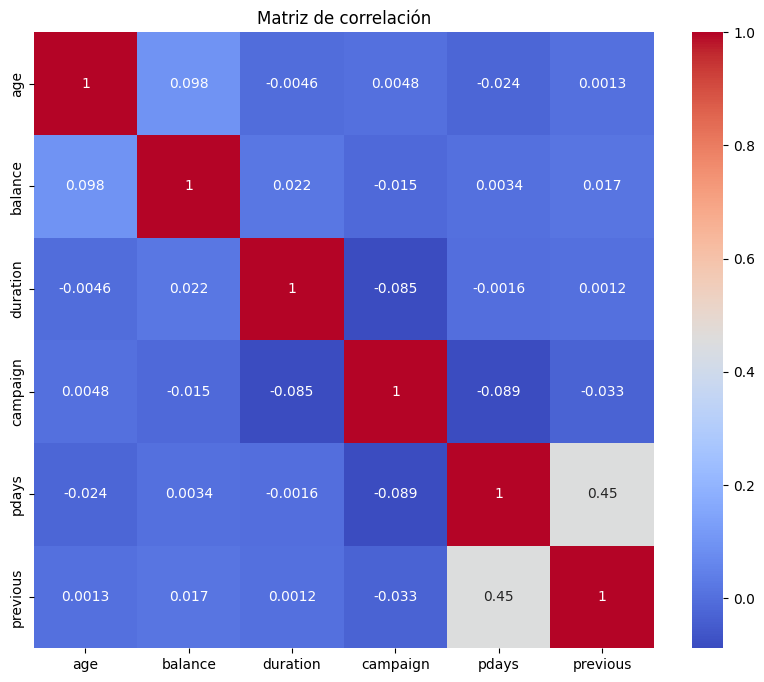

In [36]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_variables].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

**Observación**

principalmente podemos ver que muchas variables presentan correlaciones muy cercanas a 0, no hay una relación lineal muy fuerte entre ellas, de acá podemos excluir un poco a las variables `pdays` y `previous` con un valor de 0.45, lo cual es coherente ya que ambas dicen casi lo mismo con respecto al historial de contacto con el cliente en campañas anteriores. Podemos decir que no hay multicolinealidad.

Correlación de cada variable con la suscripción a depósito a plazo ('y_yes'):

y_yes                  1.000000
duration               0.394521
poutcome_success       0.306788
pdays                  0.103621
previous               0.093236
job_retired            0.079245
job_student            0.076897
education_tertiary     0.066448
marital_single         0.063526
balance                0.052838
job_management         0.032919
poutcome_other         0.031955
age                    0.025155
job_unemployed         0.020390
contact_telephone      0.014042
job_self-employed      0.000855
job_technician        -0.008970
job_housemaid         -0.015195
job_entrepreneur      -0.019662
default_yes           -0.022419
job_services          -0.027864
day_of_week           -0.028348
education_secondary   -0.036388
marital_married       -0.060260
loan_yes              -0.068185
job_blue-collar       -0.072083
campaign              -0.073172
housing_yes           -0.139173
month                    

C:\Users\elois\AppData\Local\Temp\ipykernel_27188\1275470532.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_y.values, y=correlation_with_y.index, palette='coolwarm')


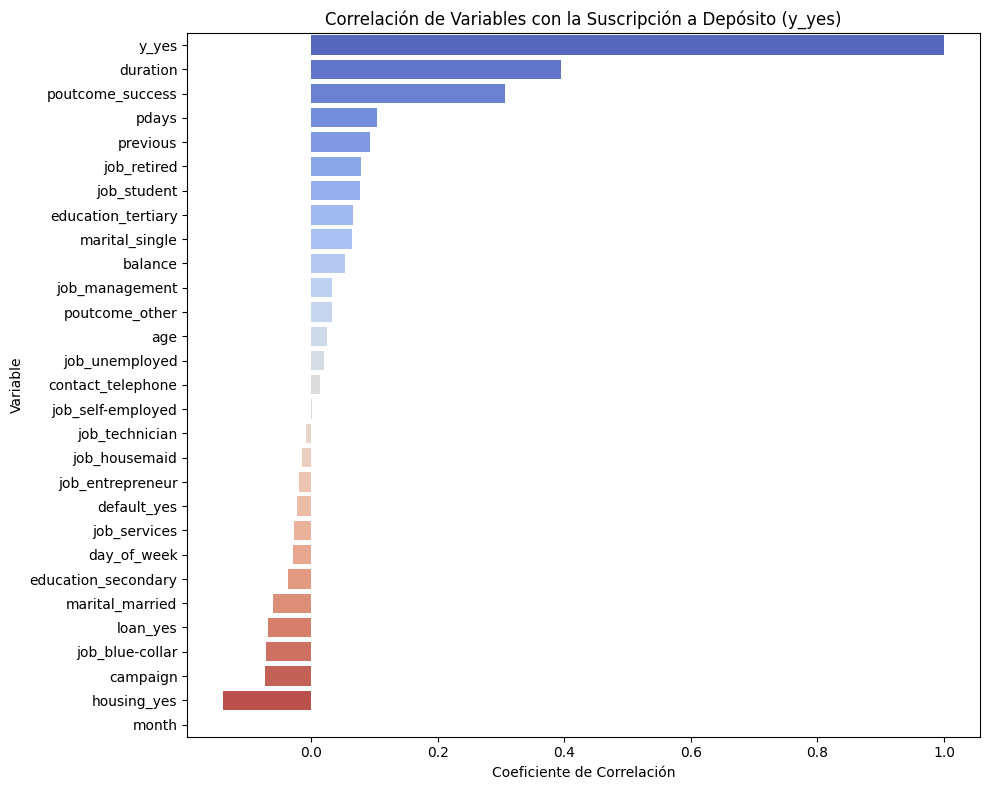

In [46]:
# Extraer las correlaciones de todas las variables con la variable objetivo 'y_yes'
correlation_with_y = correlation_matrix['y_yes'].sort_values(ascending=False)

print("Correlación de cada variable con la suscripción a depósito a plazo ('y_yes'):\n")
print(correlation_with_y)


plt.figure(figsize=(10, 8))
sns.barplot(x=correlation_with_y.values, y=correlation_with_y.index, palette='coolwarm')
plt.title('Correlación de Variables con la Suscripción a Depósito (y_yes)')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# **Algunos Insights**

1. El dataset presente un fuerte desbalance para la varuable target (y) donde el 88.30% no acepta el depósito.
2. Tenemos que hacer escalado o transformación ya que tenemos muchos outliers presentes y valores muy atípicos.
3. La variable `duration` muestra claramente una relación muy fuerte con el target, tenemos que considerar que esta variable debería de no ser incluida, ya que la idea es saber que clientes podemos contactar, y duration solo nos esta diciendo tiempo de llamada, es una acción que solo se conoce después de haber contactado al cliente, y el modelo podria hacer trampa o data leakage.
4. La variable `campaign` nos demuestra que una gran cantidad de llamadas aumenta mas la posibilidad de que un cliente no acepte hacer el depósito.
5. Esto se ve reflejado con la cantidad de personas que son contactadas por primera vez en las variables `pdays` y `previous` las cuales estan moderadamente relacionadas.
6. no se observa multicolinealidad entre las variables numéricas. 

